## Step 1: Import Libraries and Load Dataset
We prepare the environment with libraries like pandas, numpy, scikit learn, matplotlib and seaborn for data manipulation, numerical operations, visualization and scaling. Load the dataset for preprocessing.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Step 2: Inspect Data Structure and Check Missing Values

We understand dataset size, data types and identify any incomplete (missing) data that needs handling.

df.info(): Prints concise summary including count of non-null entries and data type of each column.
df.isnull().sum(): Returns the number of missing values per column.

In [14]:
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome    

## Step 3: Statistical Summary and Visualizing Outliers

Get numeric summaries like mean, median, min/max and detect unusual points (outliers). Outliers can skew models if not handled.

df.describe(): Computes count, mean, std deviation, min/max and quartiles for numerical columns.
Boxplots: Visualize spread and detect outliers using matplotlib’s boxplot().

In [15]:
df.describe()



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


C:\Users\Asus\AppData\Local\Temp\ipykernel_23000\2069499345.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df[col], vert=False)
C:\Users\Asus\AppData\Local\Temp\ipykernel_23000\2069499345.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df[col], vert=False)
C:\Users\Asus\AppData\Local\Temp\ipykernel_23000\2069499345.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df[col], vert=False)
C:\Users\Asus\AppData\Local\Temp\ipykernel_23000\2069499345.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} ins

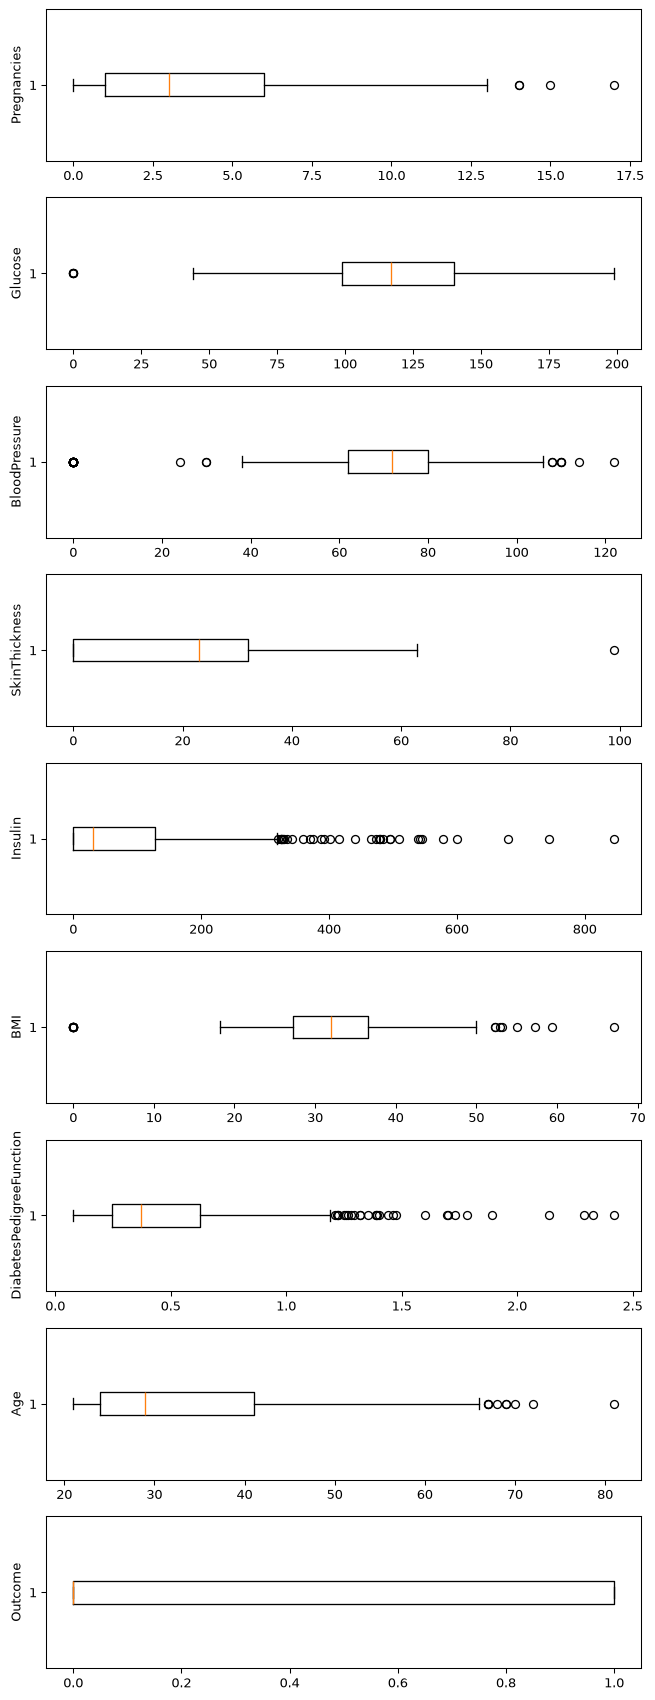

In [16]:
fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

## Step 4: Remove Outliers Using the Interquartile Range (IQR) Method

Remove extreme values beyond a reasonable range to improve model robustness.

IQR = Q3 (75th percentile) – Q1 (25th percentile).
Values below Q1 - 1.5IQR or above Q3 + 1.5IQR are outliers.
Calculate lower and upper bounds for each column separately.
Filter data points to keep only those within bounds.



In [17]:
q1, q3 = np.percentile(df['Insulin'], [25, 75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
clean_df = df[(df['Insulin'] >= lower) & (df['Insulin'] <= upper)]
clean_df.info()

<class 'pandas.DataFrame'>
Index: 734 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               734 non-null    int64  
 1   Glucose                   734 non-null    int64  
 2   BloodPressure             734 non-null    int64  
 3   SkinThickness             734 non-null    int64  
 4   Insulin                   734 non-null    int64  
 5   BMI                       734 non-null    float64
 6   DiabetesPedigreeFunction  734 non-null    float64
 7   Age                       734 non-null    int64  
 8   Outcome                   734 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 57.3 KB


## Step 5: Correlation Analysis

Understand relationships between features and the target variable (Outcome). Correlation helps gauge feature importance.

df.corr(): Computes pairwise correlation coefficients between columns.
Heatmap via seaborn visualizes correlation matrix clearly.
Sorting correlations with corr['Outcome'].sort_values() highlights features most correlated with the target.

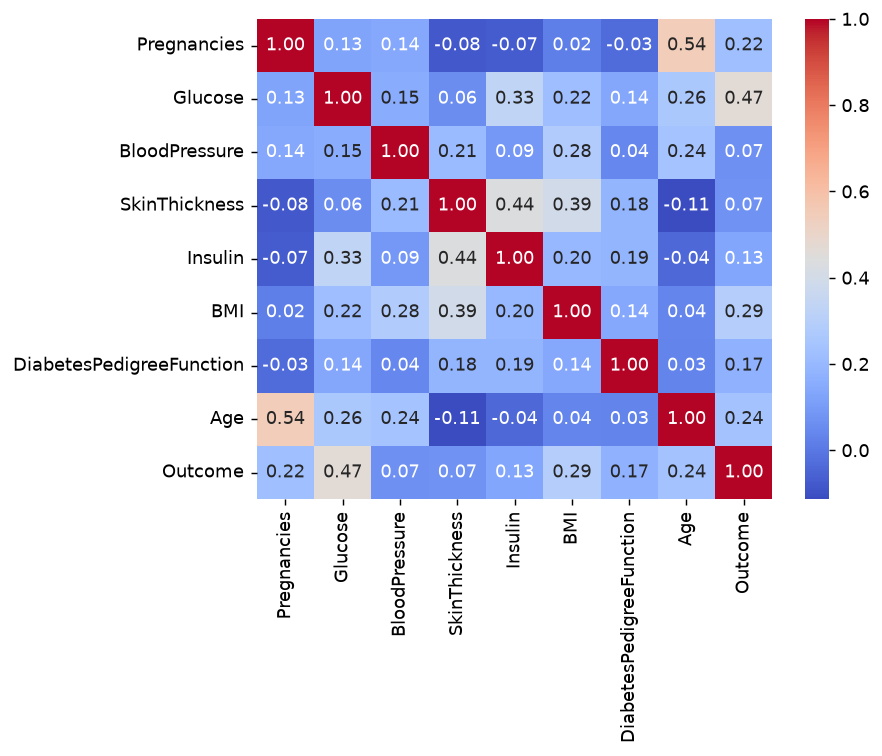

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [18]:
corr = df.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr['Outcome'].sort_values(ascending=False))

## Step 6: Visualize Target Variable Distribution

Check if target classes (Diabetes vs Not Diabetes) are balanced, affecting model training and evaluation.

plt.pie(): Pie chart to display proportion of each class in the target variable 'Outcome'.

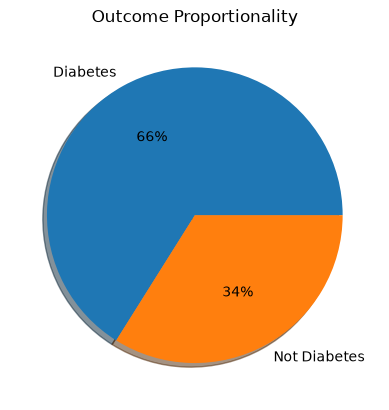

In [19]:
plt.pie(clean_df['Outcome'].value_counts(),
        labels=['Diabetes', 'Not Diabetes'],
        autopct='%.f%%', shadow=True)
plt.title('Outcome Proportionality')       
plt.show()

## Step 7: Separate Features and Target Variable

Prepare independent variables (features) and dependent variable (target) separately for modeling.

df.drop(columns=[...]): Drops the target column from features.
Direct column selection df['Outcome'] selects target column.

In [20]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

## Step 8: Feature Scaling: Normalization and Standardization

Scale features to a common range or distribution, important for many ML algorithms sensitive to feature magnitudes.

1. Normalization (Min-Max Scaling): Rescales features between 0 and 1. Good for algorithms like k-NN and neural networks.

Class: MinMaxScaler from sklearn.
.fit_transform(): Learns min/max from data and applies scaling.

In [21]:
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
print(X_normalized[:5])

[[0.35294118 0.74371859 0.59016393 0.35353535 0.         0.50074516
  0.23441503 0.48333333]
 [0.05882353 0.42713568 0.54098361 0.29292929 0.         0.39642325
  0.11656704 0.16666667]
 [0.47058824 0.91959799 0.52459016 0.         0.         0.34724292
  0.25362938 0.18333333]
 [0.05882353 0.44723618 0.54098361 0.23232323 0.11111111 0.41877794
  0.03800171 0.        ]
 [0.         0.68844221 0.32786885 0.35353535 0.19858156 0.64232489
  0.94363792 0.2       ]]


2. Standardization: Transforms features to have mean = 0 and standard deviation = 1, useful for normally distributed features.

Class: StandardScaler from sklearn.

In [22]:
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
print(X_standardized[:5])

[[ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
   0.46849198  1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 -1.28821221 -0.69289057 -1.10325546
   0.60439732 -0.10558415]
 [-0.84488505 -0.99820778 -0.16054575  0.15453319  0.12330164 -0.49404308
  -0.92076261 -1.04154944]
 [-1.14185152  0.5040552  -1.50468724  0.90726993  0.76583594  1.4097456
   5.4849091  -0.0204964 ]]
